In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "dualtest_experiments" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "DUALTEST"))

print(PROJECT_ROOT)

/home/alumno1/Downloads/NLP_Proyecto_Final-main


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from experiment_utils import prepare_records
from target_model import HFLocalTarget
from reference_model import ReferenceModel
from scoring import score_texts

/home/alumno1/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
target = HFLocalTarget(
    model_name="Qwen/Qwen2.5-1.5B",
    device="cuda"
)

reference = ReferenceModel(
    model_name="Qwen/Qwen2.5-0.5B",
    device="cuda"
)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [4]:
records = prepare_records(
    dataset_name="booktection",
    n=1000,
    random_state=7,
    balance_labels=True,
)

len(records), records[0].keys()

(1000,
 dict_keys(['id', 'dataset', 'dataset_family', 'source_dataset', 'file_path', 'label', 'estimated_membership', 'text', 'text_hash']))

In [5]:
texts = [r["text"] for r in records]
labels = [r["label"] for r in records]
ids = [r["id"] for r in records]
memberships = [r["estimated_membership"] for r in records]

len(texts), labels[:10]

(1000, [1, 0, 0, 1, 0, 0, 1, 0, 0, 0])

In [6]:
df = score_texts(
    texts=texts,
    target=target,
    reference=reference,
    dataset_name="booktection",
    label=None,
)

df["id"] = ids
df["label"] = labels
df["membership"] = memberships
df["dataset"] = "booktection"

df.head()

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


,id,label,run_length,p_rlb,edit_similarity,p_esb,prefix,ground_truth,target_completion,membership,dataset
0,booktection_06344_A.txt,1,2,0.063411,0.251799,0.000000e+00,"Valancourt, who heard these calls, and also th...",", he assured her, in a voice that trembled, bu...",", he was more than ever desirous to be of her ...",member,booktection
1,booktection_13775_A.txt,0,1,0.112642,0.259259,6.989494e-38,She pulled her leg back out of the window and ...,"in the sixties, so, you know hallucinogenic ...","in 1998, and I was 17. I was a student at the...",non_member,booktection
2,booktection_15728_A.txt,0,0,1.000000,0.275000,0.000000e+00,But shed kept the secret to herself. What had ...,"barely found out herself and then . . . oh, G...",had been waiting for a long time. Shed had fi...,non_member,booktection
3,booktection_09652_A.txt,1,0,1.000000,0.284746,1.098174e-19,"They descended the staircase together,--gaunt,...",mankind's great and terrible eye on them alon...,the whole world before them. They were in the...,member,booktection
4,booktection_15876_A.txt,0,1,0.751298,0.293233,4.831348e-32,The light refracted from each triangle was an ...,of Jasads architecture. The only part that or...,of the original design. The other half was a ...,non_member,booktection


In [7]:
cols = [
    "id",
    "dataset",
    "label",
    "membership",
    "run_length",
    "p_rlb",
    "edit_similarity",
    "p_esb",
    "prefix",
    "ground_truth",
    "target_completion",
]

df = df[cols]
df.head()

,id,dataset,label,membership,run_length,p_rlb,edit_similarity,p_esb,prefix,ground_truth,target_completion
0,booktection_06344_A.txt,booktection,1,member,2,0.063411,0.251799,0.000000e+00,"Valancourt, who heard these calls, and also th...",", he assured her, in a voice that trembled, bu...",", he was more than ever desirous to be of her ..."
1,booktection_13775_A.txt,booktection,0,non_member,1,0.112642,0.259259,6.989494e-38,She pulled her leg back out of the window and ...,"in the sixties, so, you know hallucinogenic ...","in 1998, and I was 17. I was a student at the..."
2,booktection_15728_A.txt,booktection,0,non_member,0,1.000000,0.275000,0.000000e+00,But shed kept the secret to herself. What had ...,"barely found out herself and then . . . oh, G...",had been waiting for a long time. Shed had fi...
3,booktection_09652_A.txt,booktection,1,member,0,1.000000,0.284746,1.098174e-19,"They descended the staircase together,--gaunt,...",mankind's great and terrible eye on them alon...,the whole world before them. They were in the...
4,booktection_15876_A.txt,booktection,0,non_member,1,0.751298,0.293233,4.831348e-32,The light refracted from each triangle was an ...,of Jasads architecture. The only part that or...,of the original design. The other half was a ...


In [8]:
out_dir = PROJECT_ROOT / "results"
out_dir.mkdir(exist_ok=True)

out_path = out_dir / "booktection_qwen15_qwen05_n1000.csv"
df.to_csv(out_path, index=False)

print(out_path)

/home/alumno1/Downloads/NLP_Proyecto_Final-main/results/booktection_qwen15_qwen05_n1000.csv


In [9]:
df.groupby("label")[[
    "run_length",
    "edit_similarity",
    "p_rlb",
    "p_esb"
]].mean()

,run_length,edit_similarity,p_rlb,p_esb
label,,,,
0,0.692,0.259691,0.742067,1.836281e-08
1,0.720,0.261204,0.726246,9.630691e-07


In [10]:
df.groupby("label")[[
    "run_length",
    "edit_similarity",
    "p_rlb",
    "p_esb"
]].median()

,run_length,edit_similarity,p_rlb,p_esb
label,,,,
0,0.0,0.265804,1.0,1.724036e-34
1,0.0,0.265037,1.0,1.016962e-38


In [11]:
df["log_p_esb"] = np.log10(
    np.maximum(df["p_esb"], 1e-300)
)

df.groupby("label")["log_p_esb"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,500.0,-90.654658,112.847851,-300.0,-43.506916,-33.763454,-26.000676,-5.349513
1,500.0,-110.330705,122.768200,-300.0,-300.000000,-37.992800,-28.231420,-3.317375


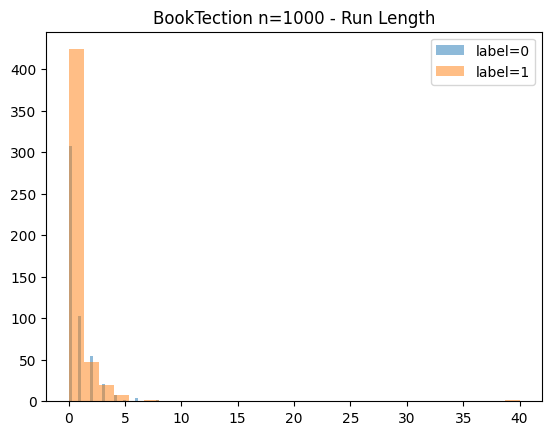

In [12]:
for label in [0, 1]:
    subset = df[df["label"] == label]
    plt.hist(
        subset["run_length"],
        bins=30,
        alpha=0.5,
        label=f"label={label}",
    )

plt.legend()
plt.title("BookTection n=1000 - Run Length")
plt.show()

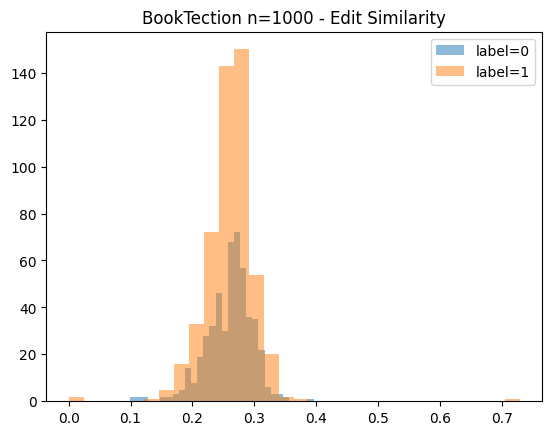

In [13]:
for label in [0, 1]:
    subset = df[df["label"] == label]
    plt.hist(
        subset["edit_similarity"],
        bins=30,
        alpha=0.5,
        label=f"label={label}",
    )

plt.legend()
plt.title("BookTection n=1000 - Edit Similarity")
plt.show()

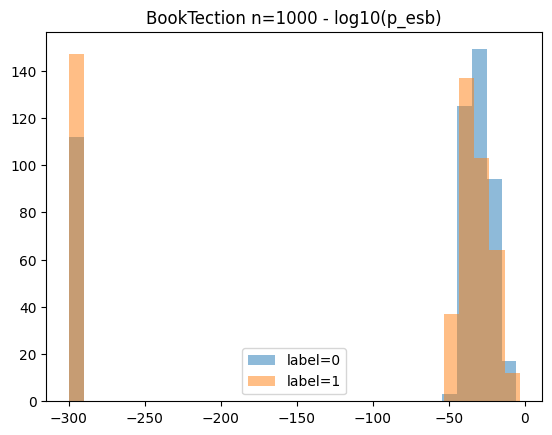

In [14]:
for label in [0, 1]:
    subset = df[df["label"] == label]
    plt.hist(
        subset["log_p_esb"],
        bins=30,
        alpha=0.5,
        label=f"label={label}",
    )

plt.legend()
plt.title("BookTection n=1000 - log10(p_esb)")
plt.show()

In [ ]:
df_normal = pd.read_csv(
    PROJECT_ROOT / "results/booktection_qwen15_qwen05_n1000.csv"
)

: 